# Exercise 01: Reading in Data and Plotting

**CBIOMES Workshop · Time Series in R**

### Why start with plots?

Before any model, look at your data. A single plot will often reveal sensor dropouts, ship-cruise gaps, ice-cover absences, instrument recalibrations, or quality-control failures that would otherwise silently corrupt every downstream model.

### What you'll learn

1. Read a CSV into R and access columns.
2. Plot a single series in **base R**
3. Generate more flexible plots in **ggplot2**.
4. Convert from **wide** to **long** format with `pivot_longer()`, the key step for plotting many variables at once.

> **No prior R experience required.** Every exercise has hints, an annotated solution, and a "common pitfalls" box. If you already know R, feel free to skip the hints and jump to the tasks.

## Setup

You are running this notebook inside the workshop **Docker container**, so most required R packages are already installed. Run `install.packages()` to install the necessary packages (`ggplot2`, `readr`, `tidyr`, `dplyr`).

The data files (`NPZ_Narragansett_Example.csv`, `time_series_balticsea.csv`) should be in the same folder as this notebook.

In [1]:
#install.packages("ggplot2")
#install.packages("dplyr")
#install.packages("tidyr")

In [2]:
# Load all packages we'll need throughout the notebook
library(ggplot2)
library(dplyr)
library(tidyr)


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




## A 60-second R primer

If you mostly work in Python or MATLAB, these are the R quirks that will trip you up most often:

| What | R syntax | Notes |
|---|---|---|
| Assign a value | `x <- 5` | `=` also works but `<-` is conventional |
| Access a column | `df$colname` | Like a dict in Python |
| Sequence 1, ..., n | `1:n` or `seq_len(n)` | Inclusive on both ends |
| Length of a vector | `length(x)` | For a data frame use `nrow(df)` |
| Pipe operator | `x %>% f() %>% g()` | "Take x, then f, then g" |
| Comments | `# like this` | No block comments |

That's enough to read every solution in this notebook.

## The NPZ dataset

The Narragansett NPZ dataset has four columns.

| Column | Units | Meaning |
|---|---|---|
| time | observation index | (dimensionless) |
| NO3 | mg N/m3 | Nutrient (nitrate) concentration |
| P | mg N/m3   | Phytoplankton concentration |
| Z | mg N/m3   | Zooplankton concentration |

Each row is one observation in time. Let's peek at it by reading in the data and using the command head afterwards:

In [3]:
npz <- as.data.frame(read.csv("NPZ_Narragansett_Example.csv"))
head(npz)
cat("Number of observations:", nrow(npz), "\n")

,time,NO3,P,Z
,<dbl>,<dbl>,<dbl>,<dbl>
1,1,0.2880,0.0379,0.0100
2,8,0.3596,0.0644,0.0006
3,15,0.3569,0.0501,0.0073
4,22,0.4147,0.0343,0.0328
5,29,0.5691,0.0558,0.0016
6,36,0.6366,0.0451,0.0065


Number of observations: 337 


---

## Exercise 1.1 — Base R Time Series Plot

**Goal:** make a first visualisation of zooplankton (`Z`) over time using base R plotting.

### Tasks

1. Extract the `Z` time series from the dataset.
2. Build a time index `1, 2, ..., T`.
3. Plot it with both points and lines, axis labels, a title, and a grid.
4. Look at the plot: do you see seasonality? Trends? Outliers?

### Hints

- Access a column: `df$colname`.
- Time index of this dataset: `time`.
- `plot( )` arguments worth knowing:
  - The first argument is the time index
  - The second arguemnt is the value for the corresponding time point or the time series
  - `type = "b"` → **b**oth points and lines
  - `pch = 16`   → filled circle marker
  - `lwd = 2`    → line width
  - `xlab`, `ylab`, `main` → labels
- Add a grid afterwards with `grid()`.

**Expected result:** a single figure showing zooplankton concentration as a function of time, with visible peaks and troughs.

<details>
<summary><b>Hint 1: click to expand</b></summary>

Start by pulling the column out into its own variable:

```r
z <- npz$Z
```
</details>

<details>
<summary><b>Hint 2: click to expand</b></summary>

Build the time index from the length of `z`:

```r
time <- npz$time 
```
</details>

<details>
<summary><b>Full solution — click to expand</b></summary>

```r
z    <- npz$Z
time <- npz$time

plot(time, z,
     type = "b", pch = 16, col = "darkblue", lwd = 2,
     xlab = "Time", ylab = "Z (mg N/m3)",
     main = "Zooplankton Dynamics")
grid()
```
</details>

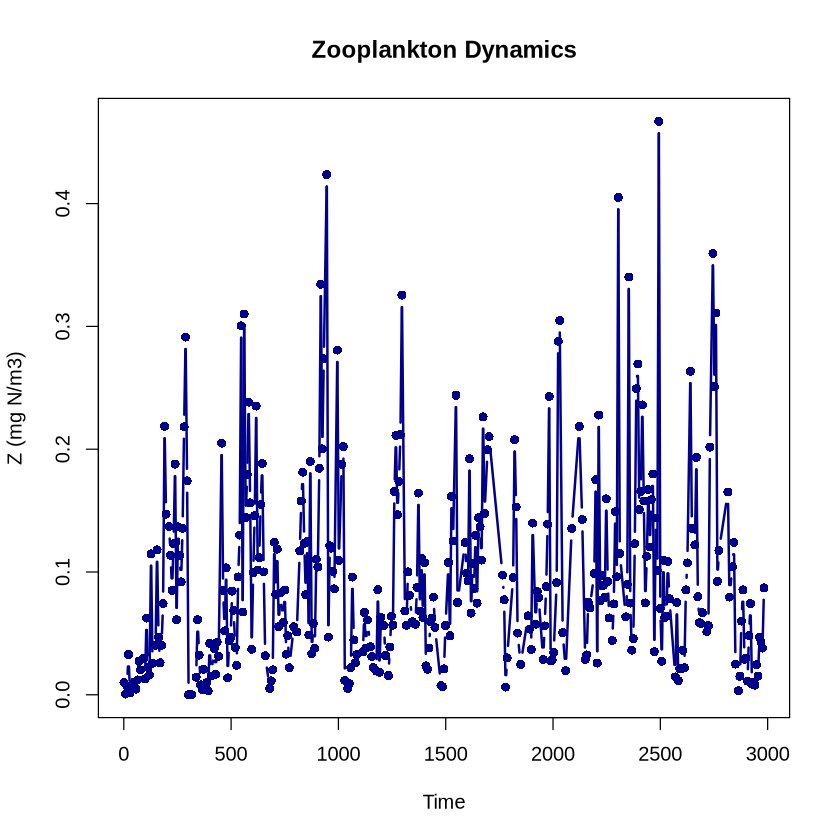

In [4]:
# Exercise 1.1 solution

# 1. Extract the zooplankton column.
z <- npz$Z

# 2. Time index
time <- npz$time

# 3. Base R plot.
#    type="b" -> both points AND lines
#    pch=16   -> filled circle marker
#    lwd=2    -> line width
plot(time, z,
     type = "b", pch = 16, col = "darkblue", lwd = 2,
     xlab = "Time", ylab = "Z (mg N/m3)",
     main = "Zooplankton Dynamics")

### Visual inspection

Run your eye across the series and ask:

- Do you observe **seasonal patterns** (recurring peaks)?
- Are there **trends** or long-term changes?
- Does the **variability** look constant over time, or does it grow/shrink?
- Any **outliers** or unusual events?

These four observations alone often determine which model class will work (Exercises 02–05 will turn each into a quantitative test).


### Common pitfalls

- `Error: object 'z' not found`: you skipped the extraction step or mistyped the column name.
- Plot does not show in JupyterLab: make sure the cell finished running.

## Exercise 1.2: Comparing multiple time series

Now we move from one variable to several. We will visit four parts:

Two variables in base R (Z and P).
Three variables in base R (Z, P, NO3)
Ten variables from a higher-dimensional dataset.

### Part 1: Two variables in base R

**Tasks:**

1. Plot `Z` as a line.
2. Add `P` to the same figure with a different color.
3. Make sure both fit on the y-axis.
4. Add a legend.

**Hints:**

- `plot()` opens a figure; `lines()` adds another series to it.
- For a shared y-axis, set `ylim = range(c(z_values, p_values))`.
- Add a legend with `legend("topright", legend = c(...), col = c(...), lty = 1)`.

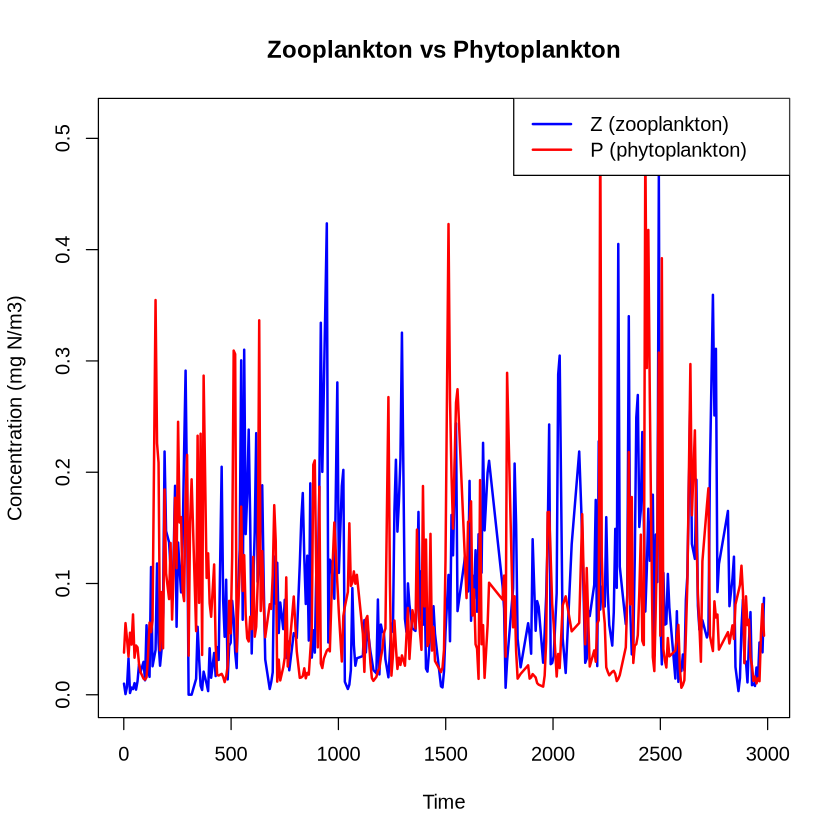

In [5]:
# Part 1: base R, two variables

z <- npz$Z
p <- npz$P

plot(time, z,
     type = "l", col = "blue", lwd = 2,
     ylim = range(c(z, p)),               # shared y-axis
     xlab = "Time", ylab = "Concentration (mg N/m3)",
     main = "Zooplankton vs Phytoplankton")
lines(time, p, col = "red", lwd = 2)      # add second series
legend("topright",
       legend = c("Z (zooplankton)", "P (phytoplankton)"),
       col = c("blue", "red"), lty = 1, lwd = 2)

**Discuss:** What differences do you see in **magnitude** and **variability**? Are there signs of interaction (e.g. P peaks slightly before Z)?

### Part 2: Three variables in base R

Add NO₃ to the previous plot. (Use the same `lines()` pattern.)

**Discuss:**

- What happens to interpretability when you add the third variable?
- Which patterns become harder to see when one variable has a much larger range than the others?

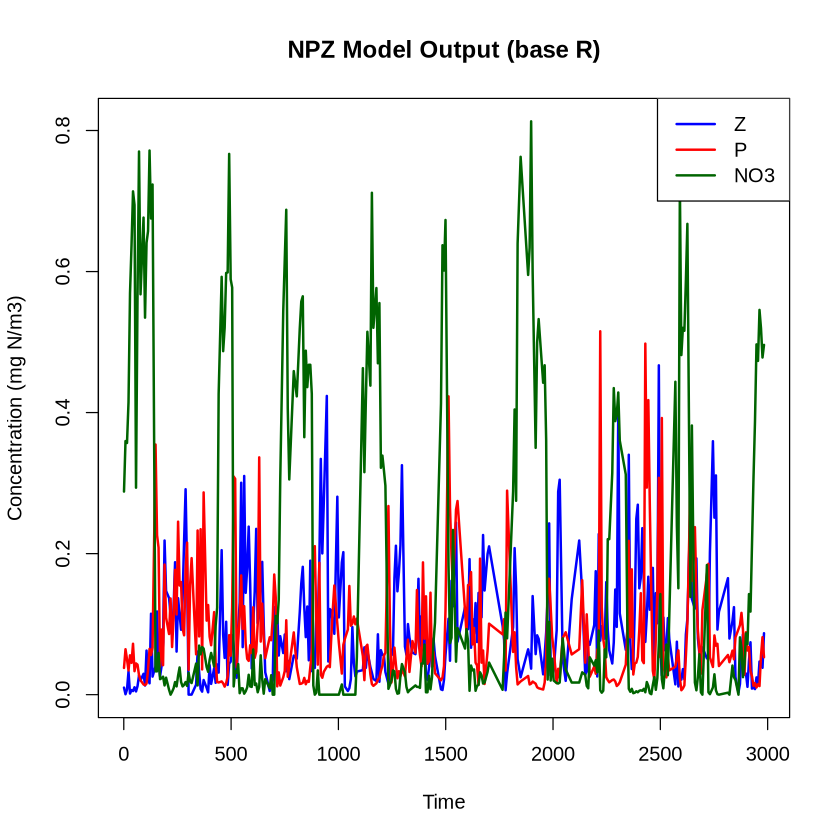

In [6]:
# Part 2: base R, three variables

n <- npz$NO3

plot(time, z,
     type = "l", col = "blue", lwd = 2,
     ylim = range(c(z, p, n)),
     xlab = "Time", ylab = "Concentration (mg N/m3)",
     main = "NPZ Model Output (base R)")
lines(time, p, col = "red",       lwd = 2)
lines(time, n, col = "darkgreen", lwd = 2)
legend("topright",
       legend = c("Z", "P", "NO3"),
       col = c("blue", "red", "darkgreen"),
       lty = 1, lwd = 2)

---

## (Optional) Exercise 2.1: Visualization with ggplot2

`ggplot2` follows the **grammar of graphics**: you describe a plot as `data` + `aesthetics` + `geometries` + `labels` + `theme`. Each piece is added with `+`. This separation makes plots easy to extend and modify later.

```
ggplot(data, aes(x = ..., y = ...)) +
    geom_line()  +     # geometry layer
    geom_point() +     # another layer
    labs(...)    +     # labels
    theme_minimal()    # styling
```

### Tasks

1. Add a `time` column to the dataset (`1, 2, …, T`).
2. Build a ggplot with `time` on the x-axis and `Z` on the y-axis.
3. Add **both** a line and points.
4. Give it a title, axis labels, and a clean theme.

### Hints

- Add a column to a data frame: `df$time <- seq_len(nrow(df))`.
- Inside `aes(...)`, refer to columns by their (backtick-quoted) name.
- Common geoms: `geom_line()`, `geom_point()`.
- Labels: `labs(title = ..., x = ..., y = ...)`.
- Themes: `theme_minimal()`, `theme_bw()`, `theme_classic()`.

<details>
<summary><b>Hint 1</b></summary>

Add the time index:
```r
npz$time <- seq_len(nrow(npz))
```
</details>

<details>
<summary><b>Hint 2</b></summary>

Skeleton:
```r
ggplot(npz, aes(x = time, y = Z)) +
    geom_line() +
    geom_point()
```
</details>

<details>
<summary><b>Full solution</b></summary>

```r
npz$time <- seq_len(nrow(npz))

ggplot(npz, aes(x = time, y = Z)) +
    geom_line(color = "steelblue") +
    geom_point(size = 2) +
    labs(title = "Zooplankton Dynamics",
         x = "Time", y = "Z (mg N/m3)") +
    theme_minimal()
```
</details>

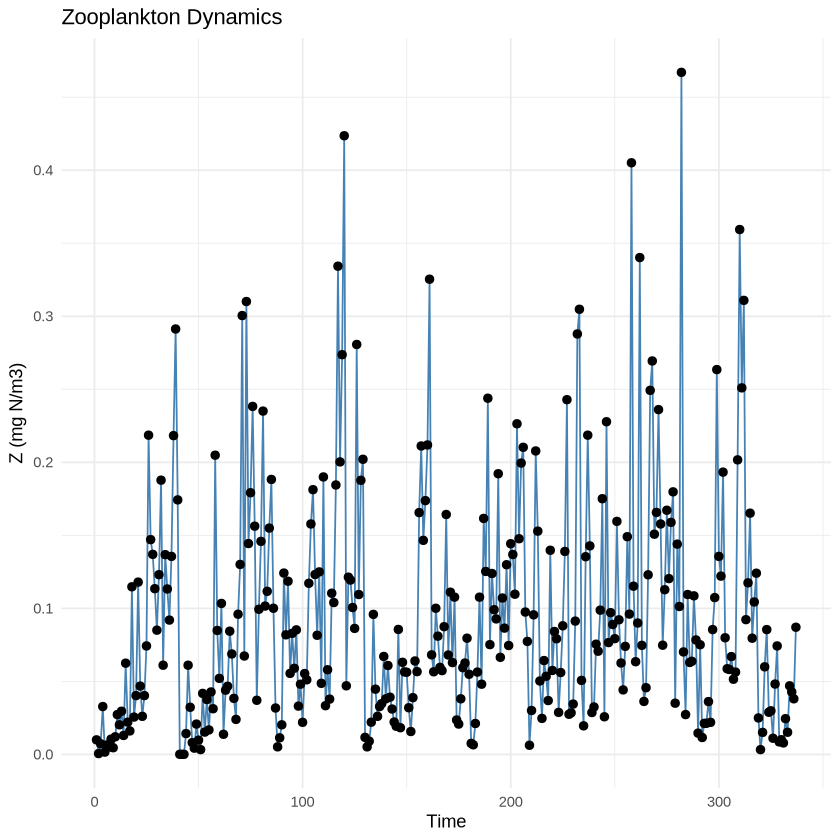

In [7]:
# Exercise 2.1 solution

# Add a numeric time index as a new column
npz$time <- seq_len(nrow(npz))

ggplot(npz, aes(x = time, y = Z)) +
    geom_line(color = "steelblue") +     # line layer
    geom_point(size = 2) +                # point layer on top
    labs(title = "Zooplankton Dynamics",
         x = "Time",
         y = "Z (mg N/m3)") +
    theme_minimal()                       # clean white background

### Discussion

- Why is it useful to separate **data**, **aesthetics**, and **geometries**?
- When would you prefer `ggplot2` over base R? (Hint: faceting, color mapping, legends are essentially free.)
- How could you extend this plot? (e.g. `geom_smooth()` for a trend line, `facet_wrap()` for multiple panels.)

### Common pitfalls

- `object 'time' not found` → you forgot to add the `time` column **before** calling `ggplot`.
- Forgetting the `+` between layers (or accidentally putting it at the start of a line — in R, `+` must end the previous line).

---

## Exercise 2.2: Comparing multiple time series

Now we move from one variable to several.

1. Three variables in ggplot2
2. Ten variables from a higher-dimensional dataset.

### Why long format?

`ggplot2` works best when each row is **one observation of one variable**. That is called *long format*. A small example:

**Wide format** (one row per time point):

| time | Z | P | NO3 |
|---|---|---|---|
| 1 | 0.4 | 1.2 | 5.1 |
| 2 | 0.5 | 1.3 | 4.9 |

**Long format** (one row per measurement):

| time | Variable | Value |
|---|---|---|
| 1 | Z   | 0.4 |
| 1 | P   | 1.2 |
| 1 | NO3 | 5.1 |
| 2 | Z   | 0.5 |
| 2 | P   | 1.3 |
| 2 | NO3 | 4.9 |

The function `pivot_longer()` does this conversion.

### Part 1: The same plot in ggplot2

This is much cleaner once we reshape to long format.

**Hints:**

- `pivot_longer(cols = ..., names_to = "Variable", values_to = "Value")`.
- Map `color = Variable` inside `aes()` and ggplot will give you a legend automatically.

In [8]:
npz_long <- npz %>%
    select(time,
           Z, P, NO3) %>%
    pivot_longer(cols      = -time,        # everything except time
                 names_to  = "Variable",
                 values_to = "Concentration")

head(npz_long)

time,Variable,Concentration
<int>,<chr>,<dbl>
1,Z,0.0100
1,P,0.0379
1,NO3,0.2880
2,Z,0.0006
2,P,0.0644
2,NO3,0.3596


time,Variable,Concentration
<int>,<chr>,<dbl>
1,Z,0.0100
1,P,0.0379
1,NO3,0.2880
2,Z,0.0006
2,P,0.0644
2,NO3,0.3596


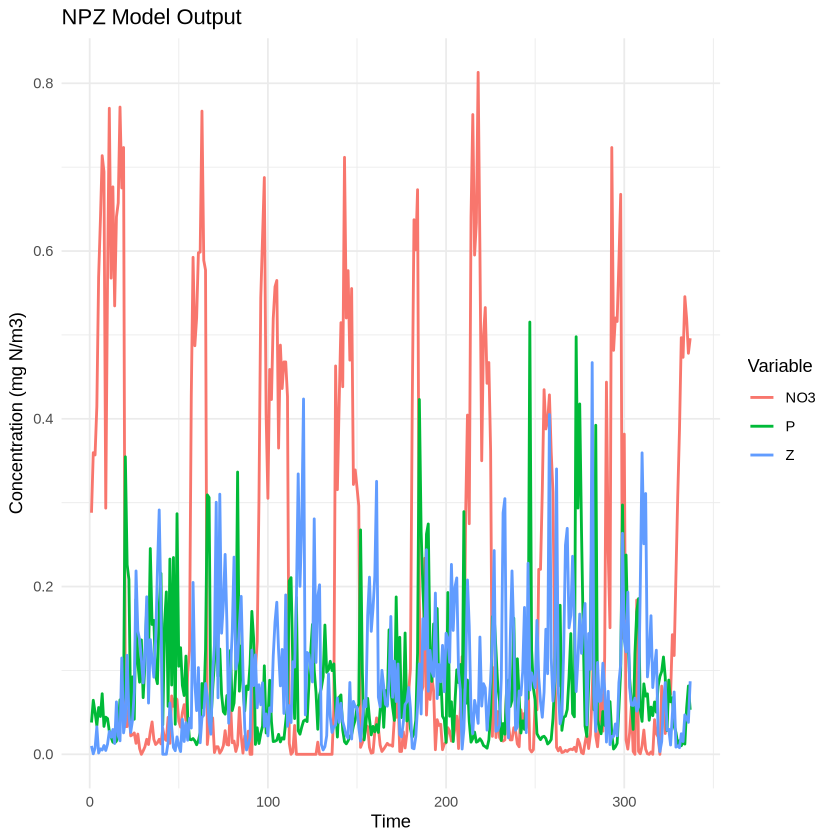

In [9]:
# Part 1: ggplot2, three variables, long format

npz_long <- npz %>%
    select(time,
           Z, P, NO3) %>%
    pivot_longer(cols      = -time,        # everything except time
                 names_to  = "Variable",
                 values_to = "Concentration")

head(npz_long)

ggplot(npz_long, aes(x = time, y = Concentration, color = Variable)) +
    geom_line(linewidth = 0.8) +
    labs(title = "NPZ Model Output",
         x = "Time",
         y = "Concentration (mg N/m3)",
         color = "Variable") +
    theme_minimal()

**(Bonus) Faceting.** When the variables live on very different scales, putting them in separate panels often reads better than overlaying them:

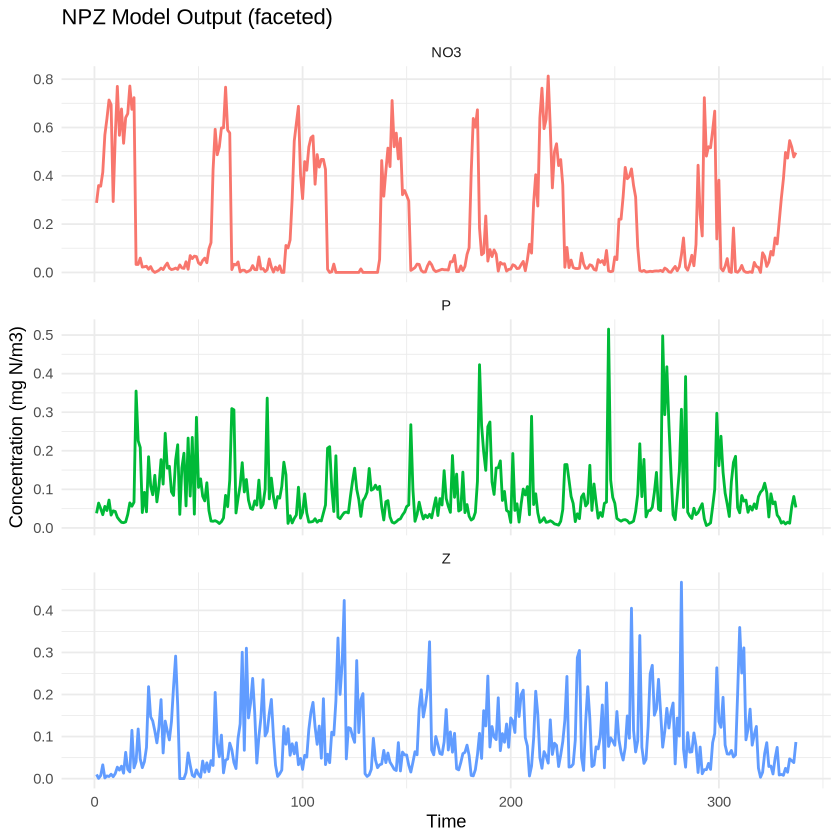

In [10]:
# Bonus: one panel per variable, with independent y-axes
ggplot(npz_long, aes(x = time, y = Concentration, color = Variable)) +
    geom_line(linewidth = 0.8, show.legend = FALSE) +
    facet_wrap(~ Variable, ncol = 1, scales = "free_y") +
    labs(title = "NPZ Model Output (faceted)",
         x = "Time", y = "Concentration (mg N/m3)") +
    theme_minimal()

### Part 2: Extension

Now we open a much wider dataset (`time_series_balticsea.csv`) and look at the **first 10 variables**.

**Tasks:**

1. Read the CSV.
2. Keep the first 10 columns.
3. Reshape to long format.
4. Plot all 10 series in one figure with color encoding.
5. Then try a **faceted** version. Which one is more readable?

**Hints:**

- Select the first 10 columns: `select(df, 1:10)`.
- Add a row index *before* pivoting: `mutate(index = row_number())`.
- `pivot_longer(cols = -index, ...)` keeps `index` as the x-axis.

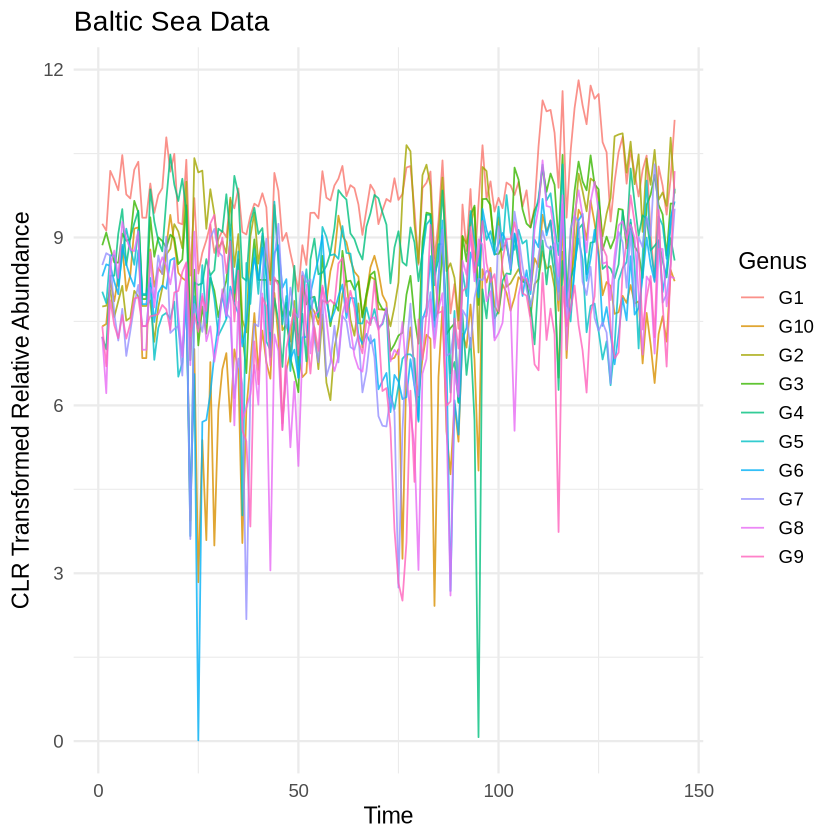

In [11]:
# Part 4: ten variables

time_series <- as.data.frame(read.csv("time_series_balticsea.csv"))

colnames(time_series)[1:10] <- paste0("G", 1:10)

time_series_long <- time_series %>%
  dplyr::select(1:10) %>%
  mutate(index = row_number()) %>%
  pivot_longer(
    cols = 1:10,
    values_to = "Abundance",
    names_to = "Genus"
  )

# Single panel — all 10 series together

ggplot(time_series_long, aes(x = index, y = Abundance, color = Genus)) +
  geom_line(linewidth = 0.5, alpha = 0.8) +
  labs(x = "Time", y = "CLR Transformed Relative Abundance", title = "Baltic Sea Data") +
  theme_minimal(base_size = 14)


In [12]:
# Same data, but faceted: one panel per variable
ggplot(ts_long, aes(x = index, y = Abundance, color = Variable)) +
    geom_line(show.legend = FALSE) +
    facet_wrap(~ Variable, ncol = 2, scales = "free_y") +
    labs(title = "Baltic Sea Data — faceted",
         x = "Time", y = "Abundance") +
    theme_minimal()

ERROR: Error: object 'ts_long' not found


### Discussion

- At what point does a single-panel plot become too crowded?
- What alternative strategies could you use for **dozens** of variables? (faceting, small multiples, **PCA**, **heatmaps**, clustering similar series together)

---

## Wrap-up

You should now be able to:

- Read a CSV into R and access columns.
- Plot a single time series in **base R** and in **ggplot2**.
- Reshape data from **wide** to **long** format with `pivot_longer()`.
- Plot multiple variables either as overlaid lines (color) or as facets.
- Recognise when a plot has too much information and needs another approach.



## Where this fits in the workflow

```
[Plot raw data]   ← you are here
       ↓
Summary stats (Exercise 02 ACF, PACF, spectrum)
       ↓
Stationarity tests (Exercise 05)
       ↓
Single-variable models (Exercises 03, 04)
       ↓
Multivariate models (Exercises 06, 08, 09, 10)
```

**Next:** descriptive summary statistics of time series to uncover patterns of the data, before we even start modelling